# Exercise 9 - Dimensionality reduction on MNIST dataset using PCA

In [15]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDClassifier
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.manifold import MDS

In [2]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(np.uint8)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
print(X_train.shape, X_test.shape)

(60000, 784) (10000, 784)


In [3]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print(f"Training time: {rf_time:.2f} seconds")
print(f"Test accuracy: {rf_acc:.4f}")

Training time: 12.24 seconds
Test accuracy: 0.9705


In [4]:
pca = PCA(n_components=0.95)
start = time.time()
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
pca_time = time.time() - start

print("Original features:", X_train.shape[1])
print("PCA features:", X_train_pca.shape[1])
print(f"PCA time: {pca_time:.2f} seconds")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")

Original features: 784
PCA features: 154
PCA time: 2.83 seconds
Explained variance: 0.9502


In [5]:
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
start = time.time()
rf_pca.fit(X_train_pca, y_train)
rf_pca_time = time.time() - start
rf_pca_acc = accuracy_score(y_test, rf_pca.predict(X_test_pca))

print(f"Training time: {rf_pca_time:.2f} seconds")
print(f"Test accuracy: {rf_pca_acc:.4f}")

Training time: 43.40 seconds
Test accuracy: 0.9488


In [6]:
print(f"Original RF: {rf_time:.2f}s, accuracy={rf_acc:.4f}")
print(f"PCA RF:      {rf_pca_time:.2f}s, accuracy={rf_pca_acc:.4f}")
print(f"Speedup:     {rf_time / rf_pca_time:.2f}x")

Original RF: 12.24s, accuracy=0.9705
PCA RF:      43.40s, accuracy=0.9488
Speedup:     0.28x


In [7]:
sgd = SGDClassifier(random_state=42, max_iter=1000, tol=1e-3)
start = time.time()
sgd.fit(X_train, y_train)
sgd_time = time.time() - start
sgd_acc = accuracy_score(y_test, sgd.predict(X_test))

print(f"Training time: {sgd_time:.2f} seconds")
print(f"Test accuracy: {sgd_acc:.4f}")

Training time: 328.16 seconds
Test accuracy: 0.8740


In [8]:
sgd_pca = SGDClassifier(random_state=42, max_iter=1000, tol=1e-3)
start = time.time()
sgd_pca.fit(X_train_pca, y_train)
sgd_pca_time = time.time() - start
sgd_pca_acc = accuracy_score(y_test, sgd_pca.predict(X_test_pca))

print(f"Training time: {sgd_pca_time:.2f} seconds")
print(f"Test accuracy: {sgd_pca_acc:.4f}")

Training time: 65.18 seconds
Test accuracy: 0.8959


In [9]:
print("\nRandom Forest")
print(f"Original: {rf_time:.2f}s, accuracy={rf_acc:.4f}")
print(f"PCA:      {rf_pca_time:.2f}s, accuracy={rf_pca_acc:.4f}")

print("\nSGD")
print(f"Original: {sgd_time:.2f}s, accuracy={sgd_acc:.4f}")
print(f"PCA:      {sgd_pca_time:.2f}s, accuracy={sgd_pca_acc:.4f}")


Random Forest
Original: 12.24s, accuracy=0.9705
PCA:      43.40s, accuracy=0.9488

SGD
Original: 328.16s, accuracy=0.8740
PCA:      65.18s, accuracy=0.8959


- PCA reduced MNIST from 784 features to roughly 150–160 while retaining 95% of the variance.
- For Random Forest, PCA made training slower in this experiment and reduced accuracy from 97.05% to 94.88%.
- For SGD, PCA reduced training time from 328.16 to 65.18 seconds (about 5× faster) and increased accuracy from 87.40% to 89.59%. Thus, PCA was much more beneficial for SGD than for Random Forest in this experiment.

# Exercise 10 - Dimensionality reduction on MNIST dataset using t-SNE

In [12]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data[:5000]
y = mnist.target[:5000].astype(np.uint8)

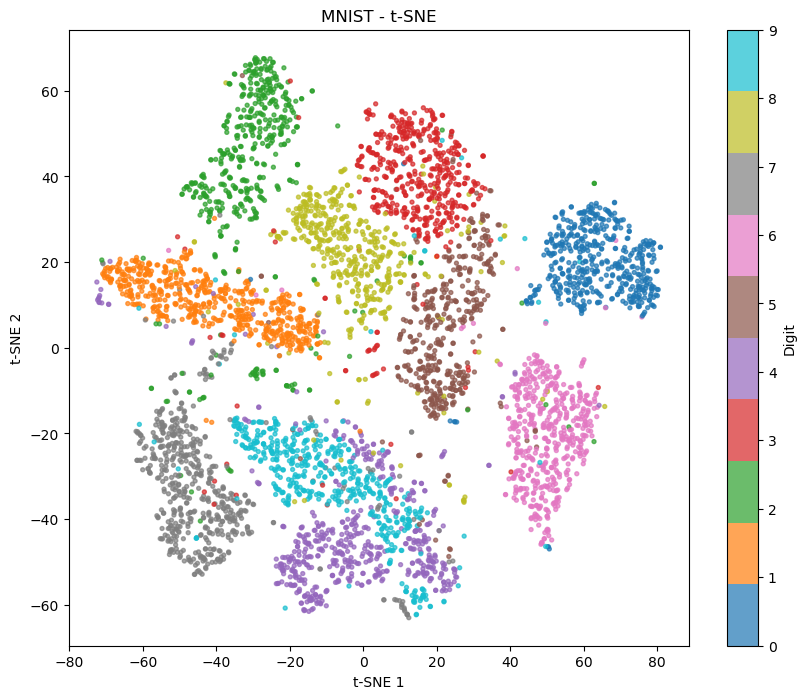

In [23]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(ticks=range(10), label="Digit")
plt.title("MNIST - t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

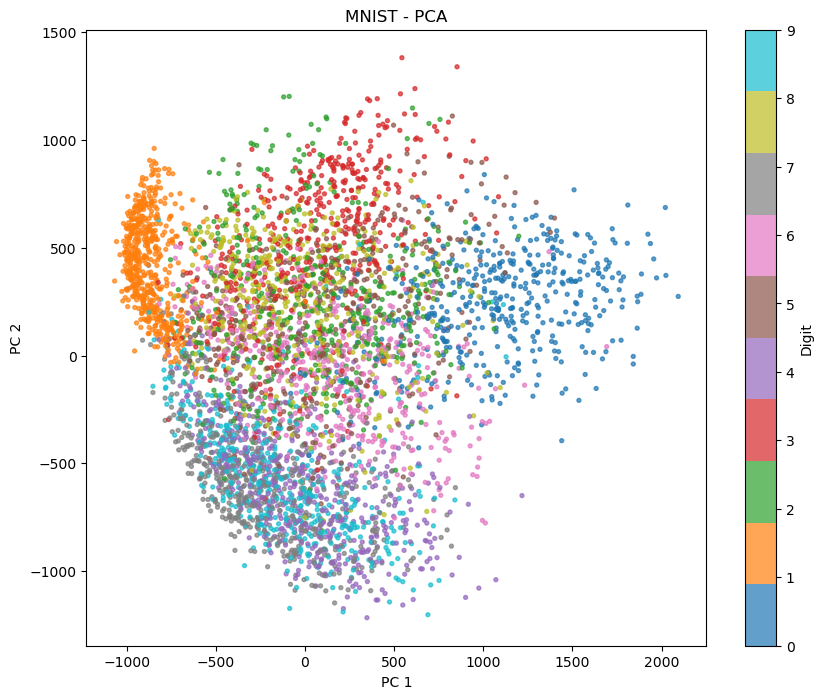

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(ticks=range(10), label="Digit")
plt.title("MNIST - PCA")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

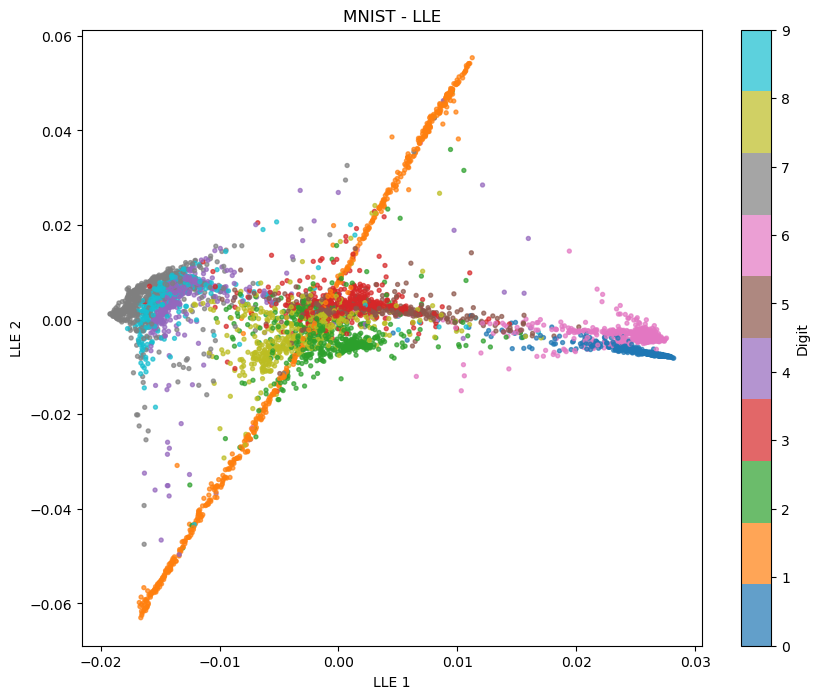

In [20]:
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_lle = lle.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_lle[:, 0], X_lle[:, 1], c=y, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(ticks=range(10), label="Digit")
plt.title("MNIST - LLE")
plt.xlabel("LLE 1")
plt.ylabel("LLE 2")
plt.show()

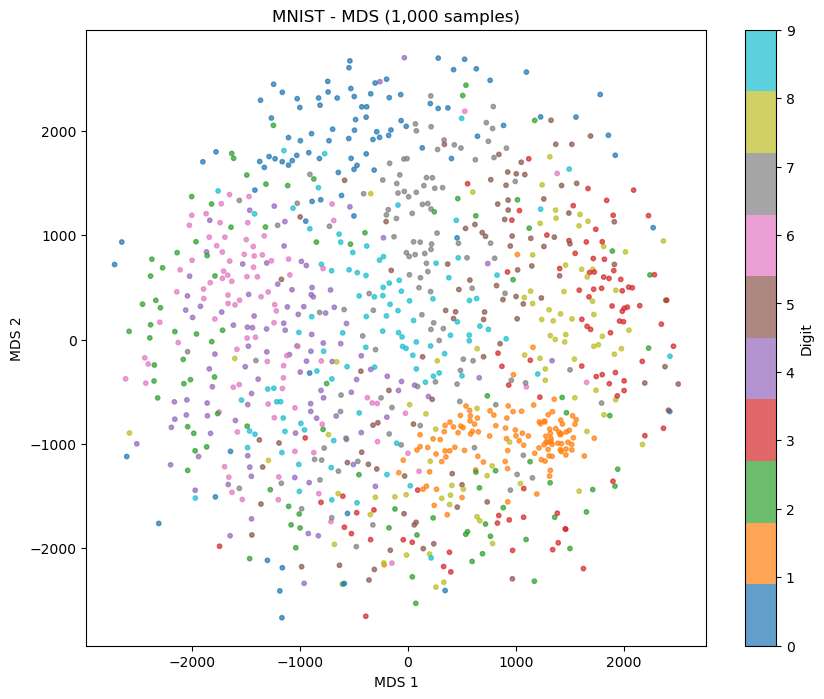

In [21]:
X_mds = X[:1000]
y_mds = y[:1000]

mds = MDS(n_components=2, random_state=42, n_init=1, normalized_stress="auto")
X_mds_2d = mds.fit_transform(X_mds)

plt.figure(figsize=(10, 8))
plt.scatter(X_mds_2d[:, 0], X_mds_2d[:, 1], c=y_mds, cmap="tab10", s=10, alpha=0.7)
plt.colorbar(ticks=range(10), label="Digit")
plt.title("MNIST - MDS (1,000 samples)")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")
plt.show()

- t-SNE preserves local neighborhoods leading to well-separated digit clusters.
- PCA preserves global variance	hence more overlap.
- LLE preserves local geometry which induces some separation and different structure.
- MDS preserves pairwise distances but is often expensive and structure depends on distances.